# Лабораторная работа 9

Тема: **Transfer learning для классификации изображений в PyTorch**  
Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** результат с обучением похожей архитектуры с нуля.

> Важно: этот ноутбук сделан как задание, а не как готовый отчёт.  
> Код даёт стартовую точку, но основная часть баллов — за ваши эксперименты и ваши живые комментарии.  
> Текстовые ответы должны соответствовать вашим графикам и числам, а не быть универсальными фразами из интернета.


## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [1]:
intro_text = """
1) transfer learning - это использование уже обученной модели для новой задачи. 
Мы берём модель, которая уже научилась находить полезные признаки и адаптируем её под свои данные.
2) Если обучать только последний слой, сеть использует уже готовые признаки и учится различать новые классы. 
Если дообучать всю сеть, она лучше подстраивается под новую задачу, но риск переобучения становится выше.
3) + Предобученная ResNet18 должна обучаться быстрее и работать лучше. 
- Она изначально обучалась на другой задаче, поэтому часть признаков может оказаться не совсем подходящей.
"""
print(intro_text)



1) transfer learning - это использование уже обученной модели для новой задачи. 
Мы берём модель, которая уже научилась находить полезные признаки и адаптируем её под свои данные.
2) Если обучать только последний слой, сеть использует уже готовые признаки и учится различать новые классы. 
Если дообучать всю сеть, она лучше подстраивается под новую задачу, но риск переобучения становится выше.
3) + Предобученная ResNet18 должна обучаться быстрее и работать лучше. 
- Она изначально обучалась на другой задаче, поэтому часть признаков может оказаться не совсем подходящей.



## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)

Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [6]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы: {2, 3, 5, 7}


In [7]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)

BATCH_SIZE = 64
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))

Размер train_subset: 3200
Размер test_subset : 4000


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [8]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


## 4. Предобученная модель: ResNet18 и заморозка слоёв

Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
Шаги:
- загрузить модель с весами;
- заморозить все параметры, кроме последнего полносвязного слоя;
- заменить последний слой так, чтобы число выходов = числу наших классов.


In [9]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# "Замораживаем" все параметры
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)
print(model_tl.fc)

Linear(in_features=512, out_features=4, bias=True)


### Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [20]:
freeze_comment = """
1) Потому что они уже умеют находить полезные признаки на изображениях, поэтому нет необходимости обучать их заново на небольшом датасете.
2) При заморозке обучается только последний слой, а при полном дообучении изменяются веса всей сети.
3) Когда НЕ замораживать: Если данных много или если новая задача сильно отличается от ImageNe, нужно переучить хотя бы последние блоки.
"""
print(freeze_comment)



1) Потому что они уже умеют находить полезные признаки на изображениях, поэтому нет необходимости обучать их заново на небольшом датасете.
2) При заморозке обучается только последний слой, а при полном дообучении изменяются веса всей сети.
3) Когда НЕ замораживать: Если данных много или если новая задача сильно отличается от ImageNe, нужно переучить хотя бы последние блоки.



## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch_tl и evaluate_tl определены.")

Функции train_one_epoch_tl и evaluate_tl определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [10]:
num_epochs_tl = 30
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/30: train_loss=1.3933, train_acc=0.3522, test_loss=1.2508, test_acc=0.4610
[TL] Эпоха 2/30: train_loss=1.2274, train_acc=0.4569, test_loss=1.2049, test_acc=0.4928
[TL] Эпоха 3/30: train_loss=1.1754, train_acc=0.4938, test_loss=1.1752, test_acc=0.5048
[TL] Эпоха 4/30: train_loss=1.1604, train_acc=0.4953, test_loss=1.2058, test_acc=0.4893
[TL] Эпоха 5/30: train_loss=1.1396, train_acc=0.5022, test_loss=1.1506, test_acc=0.5182
[TL] Эпоха 6/30: train_loss=1.1159, train_acc=0.5209, test_loss=1.1523, test_acc=0.5272
[TL] Эпоха 7/30: train_loss=1.1322, train_acc=0.5225, test_loss=1.1341, test_acc=0.5295
[TL] Эпоха 8/30: train_loss=1.1205, train_acc=0.5228, test_loss=1.1445, test_acc=0.5182
[TL] Эпоха 9/30: train_loss=1.1167, train_acc=0.5300, test_loss=1.1976, test_acc=0.4950
[TL] Эпоха 10/30: train_loss=1.1217, train_acc=0.5175, test_loss=1.1582, test_acc=0.5200
[TL] Эпоха 11/30: train_loss=1.0898, train_acc=0.5447, test_loss=1.1484, test_acc=0.5195
[TL] Эпоха 12/30: train_loss=1

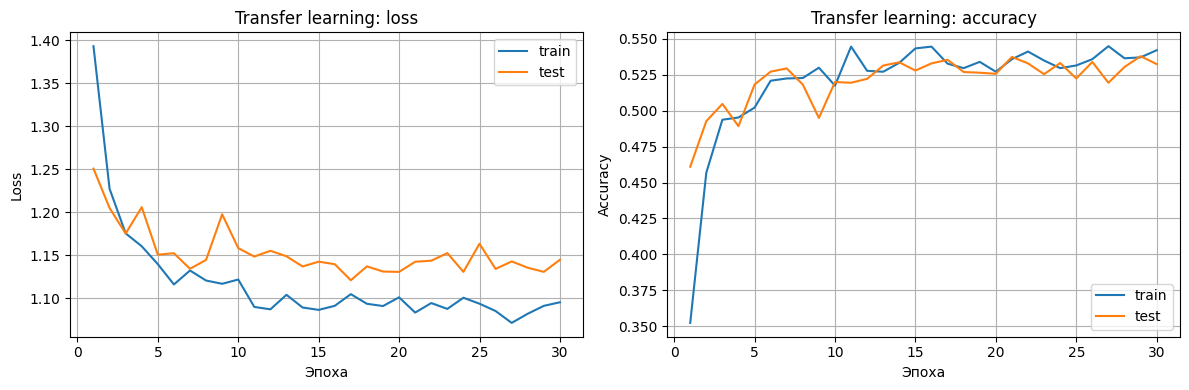

Итоговая точность TL: train=0.5422, test=0.5325


In [11]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [ ]:
tl_comment = """
1) Test accuracy росла довольно быстро только в начале обучения: с 0.4610 на 1 эпохе до 0.5182 на 5 эпохе. 
Дальше улучшения стали небольшими, и после 10 эпохи качество в основном колебалось около 0.52-0.54. 
Лучший результат получился на 29 эпохе: test_acc=0.5380.

2) Явных признаков переобучения нет. Train accuracy к концу обучения составила 0.5422, а test accuracy 0.5325, 
то есть разрыв всего около 1%.

3) Если бы я остановилась на 8 эпохах, то получила бы test_acc=0.5182. К 15-й эпохе качество выросло до 0.5280, 
а максимум за всё обучение составил 0.5380. Поэтому 8 эпох для этой модели оказалось мало.
"""
print(tl_comment)


## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [30]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

def train_one_epoch_scratch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_scratch(model, dataloader, criterion, device):
    return evaluate_tl(model, dataloader, criterion, device)

num_epochs_scratch = num_epochs_tl  # чтобы честно сравнивать
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_scratch(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_scratch(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[Scratch] Эпоха 1/30: train_loss=1.4540, train_acc=0.3891, test_loss=1.4481, test_acc=0.4585
[Scratch] Эпоха 2/30: train_loss=1.1741, train_acc=0.4822, test_loss=1.2588, test_acc=0.4903
[Scratch] Эпоха 3/30: train_loss=1.1167, train_acc=0.5228, test_loss=1.3574, test_acc=0.4557
[Scratch] Эпоха 4/30: train_loss=1.0355, train_acc=0.5616, test_loss=1.1234, test_acc=0.5517
[Scratch] Эпоха 5/30: train_loss=0.9920, train_acc=0.5837, test_loss=1.0788, test_acc=0.5545
[Scratch] Эпоха 6/30: train_loss=0.9788, train_acc=0.5794, test_loss=1.1006, test_acc=0.5168
[Scratch] Эпоха 7/30: train_loss=0.9698, train_acc=0.5972, test_loss=1.0608, test_acc=0.5465
[Scratch] Эпоха 8/30: train_loss=0.9349, train_acc=0.6094, test_loss=1.0136, test_acc=0.5917
[Scratch] Эпоха 9/30: train_loss=0.8990, train_acc=0.6281, test_loss=1.0728, test_acc=0.5695
[Scratch] Эпоха 10/30: train_loss=0.8543, train_acc=0.6503, test_loss=1.0178, test_acc=0.5990
[Scratch] Эпоха 11/30: train_loss=0.8312, train_acc=0.6597, test_loss

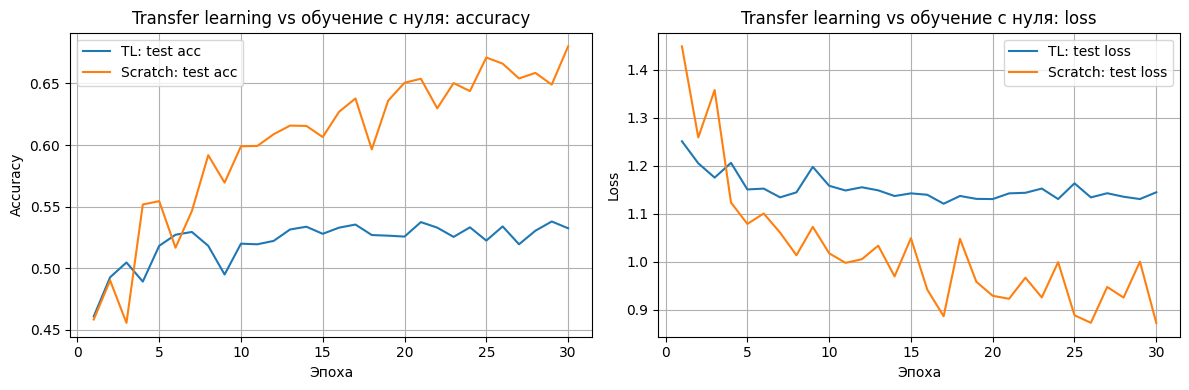

Финальная test accuracy (TL)     : 0.5325
Финальная test accuracy (Scratch): 0.6800


In [32]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [1]:
comparison_comment = """
1) В моём эксперименте результат получился неожиданным: модель, обученная с нуля, оказалась лучше transfer learning. 
TL сначала довольно быстро вышла на test_acc=0.4610 уже на 1 эпохе, но дальше почти застряла около 0.52–0.54. 
Финальная точность TL составила только 0.5325.

2) Scratch-модель стартовала похоже: на 1 эпохе test_acc=0.4585. Но дальше она продолжала улучшаться и к 8 эпохе дошла до 0.5917. 
К 30 эпохе scratch дала test_acc=0.6800, то есть заметно выше TL.

3) По loss тоже видно различие. У TL test_loss почти всё время держался около 1.12–1.15 и особо не снижался. 
У scratch test_loss уменьшился с 1.4481 до 0.8730.

4) Переобучение сильнее заметно у scratch: к концу train_acc=0.7759, а test_acc=0.6800. 
Разрыв есть, но качество на тесте всё равно лучше, чем у TL. 
У TL train_acc=0.5422 и test_acc=0.5325, то есть переобучения почти нет, но модель просто не смогла хорошо обучиться.

С моими ожиданиями это не совпало. Я думала, что предобученная ResNet18 даст лучший результат.
"""
print(comparison_comment)



1) В моём эксперименте результат получился неожиданным: модель, обученная с нуля, оказалась лучше transfer learning. 
TL сначала довольно быстро вышла на test_acc=0.4610 уже на 1 эпохе, но дальше почти застряла около 0.52–0.54. 
Финальная точность TL составила только 0.5325.

2) Scratch-модель стартовала похоже: на 1 эпохе test_acc=0.4585. Но дальше она продолжала улучшаться и к 8 эпохе дошла до 0.5917. 
К 30 эпохе scratch дала test_acc=0.6800, то есть заметно выше TL.

3) По loss тоже видно различие. У TL test_loss почти всё время держался около 1.12–1.15 и особо не снижался. 
У scratch test_loss уменьшился с 1.4481 до 0.8730.

4) Переобучение сильнее заметно у scratch: к концу train_acc=0.7759, а test_acc=0.6800. 
Разрыв есть, но качество на тесте всё равно лучше, чем у TL. 
У TL train_acc=0.5422 и test_acc=0.5325, то есть переобучения почти нет, но модель просто не смогла хорошо обучиться.

С моими ожиданиями это не совпало. Я думала, что предобученная ResNet18 даст лучший результа

## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать. 
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах? 

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`. 
Что происходит с пространственным размером картинки по мере прохождения через слои сети? 
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [1]:
tl_problem_comment = """
ResNet18 обучалась на больших изображениях 224×224, а CIFAR-10 содержит картинки размером всего 32×32.
Изображение быстро сжимается, и часть деталей теряется. Поэтому transfer learning здесь работает хуже, чем ожидалось.
Исправить это можно, например, увеличив картинки до 224×224 или разморозив часть слоёв для дообучения.
"""
print(tl_problem_comment)


ResNet18 обучалась на больших изображениях 224×224, а CIFAR-10 содержит картинки размером всего 32×32.
Изображение быстро сжимается, и часть деталей теряется. Поэтому transfer learning здесь работает хуже, чем ожидалось.
Исправить это можно, например, увеличив картинки до 224×224 или разморозив часть слоёв для дообучения.



In [12]:
# Решение проблемы TL: делаем размер картинок как у ImageNet
transform_tl_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

full_train_224 = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform_tl_224
)

full_test_224 = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform_tl_224
)

train_dataset_224 = Subset(full_train_224, train_loader.dataset.indices)
test_dataset_224 = Subset(full_test_224, test_loader.dataset.indices)

train_loader_224 = DataLoader(
    train_dataset_224,
    batch_size=train_loader.batch_size,
    shuffle=True,
    num_workers=0
)

test_loader_224 = DataLoader(
    test_dataset_224,
    batch_size=test_loader.batch_size,
    shuffle=False,
    num_workers=0
)

In [13]:
# Новая TL-модель на картинках 224×224

model_tl_224 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_tl_224.parameters():
    param.requires_grad = False

model_tl_224.fc = nn.Linear(
    model_tl_224.fc.in_features,
    len(selected_class_indices)
)

model_tl_224 = model_tl_224.to(device)

optimizer_tl_224 = torch.optim.Adam(
    model_tl_224.fc.parameters(),
    lr=1e-3
)

history_tl_224 = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

num_epochs_224 = 15

for epoch in range(1, num_epochs_224 + 1):
    train_loss, train_acc = train_one_epoch_tl(
        model_tl_224,
        train_loader_224,
        optimizer_tl_224,
        criterion,
        device
    )

    test_loss, test_acc = evaluate_tl(
        model_tl_224,
        test_loader_224,
        criterion,
        device
    )

    history_tl_224["train_loss"].append(train_loss)
    history_tl_224["train_acc"].append(train_acc)
    history_tl_224["test_loss"].append(test_loss)
    history_tl_224["test_acc"].append(test_acc)

    print(f"[TL 224] Эпоха {epoch}/{num_epochs_224}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL 224] Эпоха 1/15: train_loss=1.0892, train_acc=0.5437, test_loss=0.8022, test_acc=0.7288
[TL 224] Эпоха 2/15: train_loss=0.7232, train_acc=0.7425, test_loss=0.6656, test_acc=0.7618
[TL 224] Эпоха 3/15: train_loss=0.6197, train_acc=0.7728, test_loss=0.5950, test_acc=0.7847
[TL 224] Эпоха 4/15: train_loss=0.5611, train_acc=0.7978, test_loss=0.5591, test_acc=0.7935
[TL 224] Эпоха 5/15: train_loss=0.5339, train_acc=0.8044, test_loss=0.5418, test_acc=0.7995
[TL 224] Эпоха 6/15: train_loss=0.4980, train_acc=0.8153, test_loss=0.5435, test_acc=0.7983
[TL 224] Эпоха 7/15: train_loss=0.4850, train_acc=0.8150, test_loss=0.5180, test_acc=0.8010
[TL 224] Эпоха 8/15: train_loss=0.4760, train_acc=0.8269, test_loss=0.5239, test_acc=0.8043
[TL 224] Эпоха 9/15: train_loss=0.4634, train_acc=0.8250, test_loss=0.5147, test_acc=0.8070
[TL 224] Эпоха 10/15: train_loss=0.4548, train_acc=0.8319, test_loss=0.5142, test_acc=0.8030
[TL 224] Эпоха 11/15: train_loss=0.4496, train_acc=0.8284, test_loss=0.5050, te

In [16]:
print(f"TL 224×224: test_acc = {history_tl_224['test_acc'][-1]:.4f}")

TL 224×224: test_acc = 0.8115


## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [17]:
final_summary = """
1) После этой работы я бы сначала пробовала transfer learning, если данных немного и есть готовая предобученная модель. 
В моём эксперименте после увеличения изображений до 224×224 ResNet18 получила test_acc=0.8115, что оказалось лучше обучения с нуля (0.6800).

2)Обучение с нуля имеет смысл, если данных много или если предобученная модель плохо подходит под задачу. 
Например как у меня, transfer learning на изображениях 32×32 застрял на test_acc=0.5325, а модель с нуля смогла дойти до 0.6800.

3)Из настроек разумными по умолчанию для меня стали Adam с lr=1e-3 и примерно 10–15 эпох обучения. 
!!!Ещё один важный вывод - нужно учитывать, под какие данные изначально обучалась предобученная модель. 
В моём случае увеличение изображений с 32×32 до 224×224 дало самый большой прирост качества.
"""
print(final_summary)


1) После этой работы я бы сначала пробовала transfer learning, если данных немного и есть готовая предобученная модель. 
В моём эксперименте после увеличения изображений до 224×224 ResNet18 получила test_acc=0.8115, что оказалось лучше обучения с нуля (0.6800).

2)Обучение с нуля имеет смысл, если данных много или если предобученная модель плохо подходит под задачу. 
Например как у меня, transfer learning на изображениях 32×32 застрял на test_acc=0.5325, а модель с нуля смогла дойти до 0.6800.

3)Из настроек разумными по умолчанию для меня стали Adam с lr=1e-3 и примерно 10–15 эпох обучения. 
!!!Ещё один важный вывод - нужно учитывать, под какие данные изначально обучалась предобученная модель. 
В моём случае увеличение изображений с 32×32 до 224×224 дало самый большой прирост качества.

